In [125]:
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

### Caricamento Dati

In [126]:
CSV_files = {
    "customers":           r"output/customers.csv",
    "geolocation_dataset": r"output/geolocation_dataset.csv",
    "order_items":         r"output/orders_items.csv",
    "order_payments":      r"output/order_payments.csv",
    "order_review":        r"output/order_review.csv",
    "order_dataset":       r"output/order_dataset.csv",
    "list_product":        r"output/list_product.csv",
    "list_seller":         r"output/list_seller.csv"
}

dataframes = {name: pd.read_csv(path) for name, path in CSV_files.items()}

df_customers           = dataframes["customers"]
df_orders_items        = dataframes["order_items"]
df_order_payments      = dataframes["order_payments"]
df_order_review        = dataframes["order_review"]
df_order_dataset       = dataframes["order_dataset"]
df_list_product        = dataframes["list_product"]
df_list_seller         = dataframes["list_seller"]
df_geolocation_dataset = dataframes["geolocation_dataset"]

### CREAZIONE DI DATAFRAME GLOBAL

#### Dataframe global (aggregazione per ordini)

In [127]:
# 1. Merge fra seller e geolocation
df_seller_geo = df_list_seller.merge(
    df_geolocation_dataset,
    on='geolocation_zip_code_prefix',
    how='left'
)
#rename lat, lng, city, state
df_seller_geo=df_seller_geo.rename(columns={'geolocation_lat':'seller_lat','geolocation_lng':'seller_lng','geolocation_city':'seller_city','geolocation_state':'seller_state'})
#dal merge ci sono 7 valori nulli per lat, lng e state >> rimpiazzo i valori con 0 e missing
m_lat=df_seller_geo['seller_lat'].mean()
m_lng=df_seller_geo['seller_lng'].mean()
df_seller_geo['seller_lat'] = df_seller_geo['seller_lat'].fillna(m_lat)
df_seller_geo['seller_lng'] = df_seller_geo['seller_lng'].fillna(m_lng)
df_seller_geo['seller_city'] = df_seller_geo['seller_city'].fillna('missing')
df_seller_geo['seller_city'] = df_seller_geo['seller_city'].fillna('missing')

# 2. Merge fra customers e geolocation
df_customer_geo = df_customers.merge(
    df_geolocation_dataset,
    on='geolocation_zip_code_prefix', 
    how='left'
)
#rename lat, lng, city, state
df_customer_geo=df_customer_geo.rename(columns={'geolocation_lat':'customer_lat','geolocation_lng':'customer_lng','geolocation_city':'customer_city','geolocation_state':'customer_state'})
#dal merge ci sono 7 valori nulli per lat, lng e state >> rimpiazzo i valori con 0 e missing
m_lat=df_customer_geo['customer_lat'].mean()
m_lng=df_customer_geo['customer_lng'].mean()
df_customer_geo['customer_lat'] = df_customer_geo['customer_lat'].fillna(m_lat)
df_customer_geo['customer_lng'] = df_customer_geo['customer_lng'].fillna(m_lng)
df_customer_geo['customer_city'] = df_customer_geo['customer_city'].fillna('missing')
df_customer_geo['customer_state'] = df_customer_geo['customer_state'].fillna('missing')

# 3. Aggregazione order_items per order_id
agg_orders_items = (df_orders_items.groupby('order_id', as_index = False).agg(
    total_items=('order_item_id', 'count'),       # numero di prodotti venduti
    total_price=('eur_price', 'sum'),                 # somma prezzi
    freight_total=('eur_freight_value', 'sum'),       # somma costi spedizione
    freight_avg=('eur_freight_value', 'mean'),        # media costi spedizione
    first_shipping_limit=('shipping_limit_date', 'min')  # primo limite spedizione
)
)

# 4. Aggregazione order_payments per order_id
agg_order_payments = (
    df_order_payments
    .groupby('order_id', as_index=False)
    .agg(
        total_payment_value= ('eur_total_payment_value', 'sum'),
        payment_installments= ('payment_installments', 'max'),
        payment_type         = ('payment_type', 'first')
    )
)

# 5. Aggregazione order_review per order_id
agg_order_review = (
    df_order_review
    .groupby('order_id', as_index=False)
    .agg(
    avg_review=('review_score', 'mean'),
    num_reviews=('review_score', 'count'),
    firs_review_date = ('review_creation_date', 'min'),
    first_review_answer = ('review_answer_timestamp', 'min')
    )
)

# 6. Aggregazione list_product per order_id
agg_list_products = (
    df_orders_items
    .merge(df_list_product, on='product_id', how='left')
    .groupby('order_id', as_index=False)
    .agg(
        num_products=('product_id', 'count'),
        num_categories=('product_category_name_english', 'nunique')
    )
)

# . Aggregazione list_seller per order_id
agg_seller = (
    df_orders_items
    .merge(df_seller_geo, on='seller_id', how='left')
    .groupby('order_id', as_index=False)
    .agg(
        num_sellers = ('seller_id', 'nunique'),
        seller_lat = ('seller_lat', 'mean'),
        seller_lng = ('seller_lng', 'mean'),
        seller_city = ('seller_city', 'first'),
        seller_state = ('seller_state', 'first')
    )   
)        

# Merge
df_global = df_order_dataset.merge(df_customer_geo, on='customer_id', how='left') \
                     .merge(agg_orders_items, on='order_id', how='left') \
                     .merge(agg_order_review, on='order_id', how='left') \
                     .merge(agg_order_payments, on='order_id', how='left') \
                     .merge(agg_list_products, on='order_id', how='left') \
                     .merge(agg_seller, on='order_id', how='left').groupby('order_id').first()

In [128]:
df_global.info()

<class 'pandas.DataFrame'>
Index: 99441 entries, 00010242fe8c5a6d1ba2dd792cb16214 to fffe41c64501cc87c801fd61db3f6244
Data columns (total 36 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   customer_id                    99441 non-null  str    
 1   order_status                   99441 non-null  str    
 2   order_purchase_timestamp       99441 non-null  str    
 3   order_approved_at              99281 non-null  str    
 4   order_delivered_carrier_date   97658 non-null  str    
 5   order_delivered_customer_date  96476 non-null  str    
 6   order_estimated_delivery_date  99441 non-null  str    
 7   delivery_delay_days            96476 non-null  float64
 8   actual_delivery_days           96476 non-null  float64
 9   customer_unique_id             99441 non-null  str    
 10  geolocation_zip_code_prefix    99441 non-null  int64  
 11  customer_city                  99441 non-null  str    
 12  cust

In [129]:
#PULIZIA DATI

# 1768 ordini non hanno review - Inserisco 0 al posto del valore nullo
df_global['avg_review'] = df_global['avg_review'].fillna(0)
df_global['num_reviews'] = df_global['num_reviews'].fillna(0)
# Feature booleana che identifica 0 come valore nullo e non come score
df_global['has_review'] = df_global['num_reviews'] > 0

# Controllo i valori nulli (97277)
cols_items_seller = [
    'total_items', 'total_price', 'freight_total', 'freight_avg',
    'num_products', 'num_categories', 'num_sellers',
    'seller_city', 'seller_state'
]
rows_with_nulls = df_global[df_global[cols_items_seller].isna().any(axis=1)]
same_nulls = rows_with_nulls[cols_items_seller].isna().all(axis=1)

#Sostituisco i valori stringa con "unknown"
cat_cols = ['seller_city', 'seller_state']
df_global[cat_cols] = df_global[cat_cols].fillna('unknown')
df_global['has_items'] = df_global['total_items'] > 0

# Sostituisco null nei valori numerici dei pagamenti
df_global['total_payment_value'] = df_global['total_payment_value'].fillna(0)
df_global['payment_installments'] = df_global['payment_installments'].fillna(0)
# Sostituisco null nel metodo di pagamento con 'unknown'
df_global['payment_type'] = df_global['payment_type'].fillna('unknown')
# Facoltativo: feature booleana se ordine ha pagamento
df_global['has_payment'] = df_global['total_payment_value'] > 0
#calcolo distanza tra customer e seller
df_global['distance_customer_seller'] = np.sqrt((df_global['customer_lat'] - df_global['seller_lat'])**2 + (df_global['customer_lng'] - df_global['seller_lng'])**2)
#sostituisco null con 0
df_global['distance_customer_seller'] = df_global['distance_customer_seller'].fillna(0)
#sostituisco null di seller lat e lng con valori fuori dal Brasile per poi in caso escluderli
n_lat=6
n_lng=-27
df_global['seller_lat'] = df_global['seller_lat'].fillna(n_lat)
df_global['seller_lng'] = df_global['seller_lng'].fillna(n_lng)
#sostituisco null di customer lat e lng con 
df_global['customer_lat'] = df_global['customer_lat'].fillna(n_lat)
df_global['customer_lng'] = df_global['customer_lng'].fillna(n_lng)

In [130]:
df_global.info()

<class 'pandas.DataFrame'>
Index: 99441 entries, 00010242fe8c5a6d1ba2dd792cb16214 to fffe41c64501cc87c801fd61db3f6244
Data columns (total 40 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   customer_id                    99441 non-null  str    
 1   order_status                   99441 non-null  str    
 2   order_purchase_timestamp       99441 non-null  str    
 3   order_approved_at              99281 non-null  str    
 4   order_delivered_carrier_date   97658 non-null  str    
 5   order_delivered_customer_date  96476 non-null  str    
 6   order_estimated_delivery_date  99441 non-null  str    
 7   delivery_delay_days            96476 non-null  float64
 8   actual_delivery_days           96476 non-null  float64
 9   customer_unique_id             99441 non-null  str    
 10  geolocation_zip_code_prefix    99441 non-null  int64  
 11  customer_city                  99441 non-null  str    
 12  cust

In [131]:
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
df_global.index
df_c=df_global.corr(numeric_only=True)['actual_delivery_days'].sort_values(ascending=False)
df_c

actual_delivery_days           1.000000
delivery_delay_days            0.607716
distance_customer_seller       0.389207
geolocation_zip_code_prefix    0.271002
customer_lat                   0.257661
freight_avg                    0.215475
freight_total                  0.167043
customer_lng                   0.112034
total_payment_value            0.069455
total_price                    0.054667
payment_installments           0.051797
seller_lat                     0.035600
has_items                     -0.002824
has_payment                   -0.014125
total_items                   -0.019435
num_products                  -0.019435
seller_lng                    -0.027739
num_categories                -0.027853
num_reviews                   -0.033174
num_sellers                   -0.040323
has_review                    -0.052695
avg_review                    -0.332543
Name: actual_delivery_days, dtype: float64

0.0
0.8419429126787941
0.0


actual_delivery_days           1.000000
delivery_delay_days            0.565185
cube_distance                  0.439605
sqrt_distance                  0.438900
distance_customer_seller       0.409668
geolocation_zip_code_prefix    0.283837
customer_lat                   0.261732
freight_avg                    0.231155
freight_total                  0.185914
customer_lng                   0.118944
total_payment_value            0.071326
total_price                    0.056106
seller_lat                     0.054558
payment_installments           0.053972
has_payment                   -0.015166
total_items                   -0.020761
num_products                  -0.020761
num_categories                -0.028842
num_reviews                   -0.031851
num_sellers                   -0.041878
seller_lng                    -0.045726
has_review                    -0.052184
avg_review                    -0.346707
has_items                           NaN
Name: actual_delivery_days, dtype: float

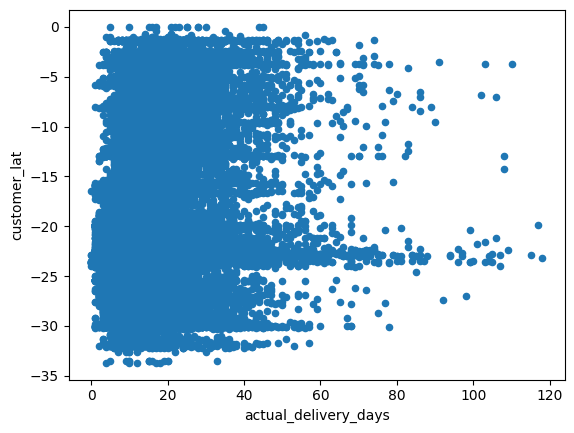

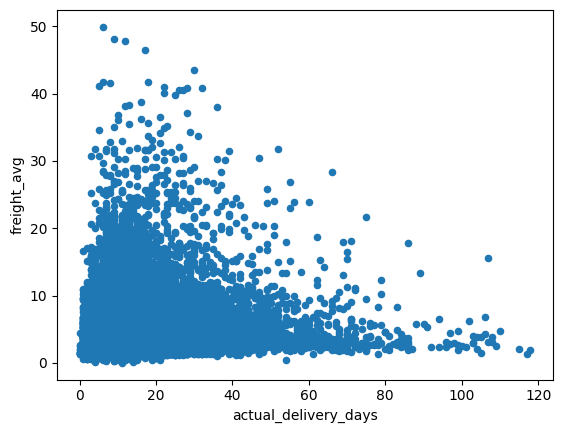

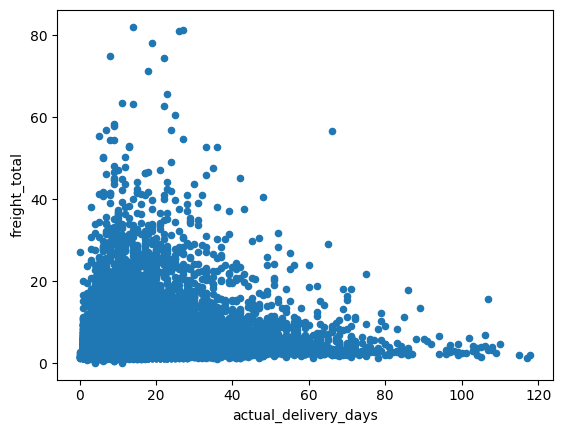

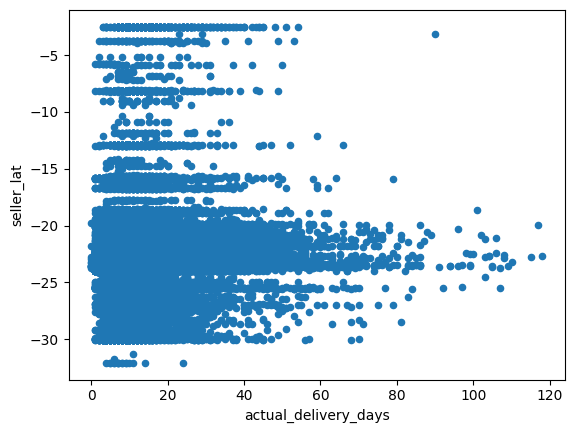

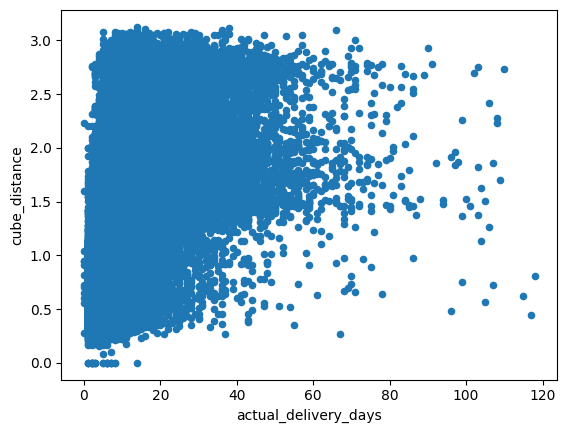

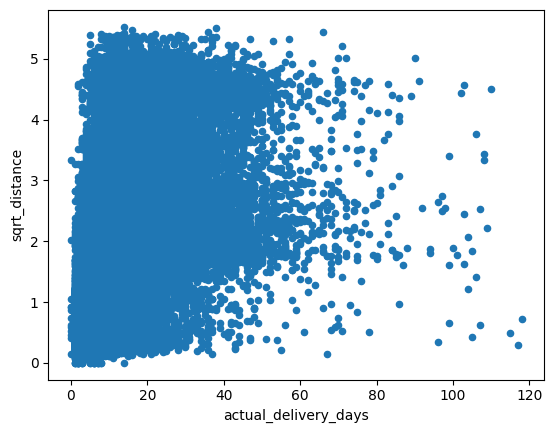

In [132]:
#limitiamo actual_delivery_days a 120
df_global = df_global[df_global['actual_delivery_days']<120]
#limitiamo customer_lat a maggiore di 0
df_global = df_global[df_global['customer_lat']<0]
#limitiamo freight_avg a max 50
df_global = df_global[df_global['freight_avg']<50]
#limitiamo total_payment_value a max 1000
df_global = df_global[df_global['total_payment_value']<1000]
#limitiamo freight_avg a tutti i maggiori di 0
df_global = df_global[df_global['freight_avg']>0]
#limitiamo freight_total a max 100
df_global = df_global[df_global['freight_total']<100]
#grafici delivery_days vs features
df_global.plot.scatter(x='actual_delivery_days', y='customer_lat')
df_global.plot.scatter(x='actual_delivery_days', y='freight_avg')
df_global.plot.scatter(x='actual_delivery_days', y='freight_total')
df_global.plot.scatter(x='actual_delivery_days', y='seller_lat')
#creiamo nuova colonna radice quadrata di distance_customer_seller
df_global['sqrt_distance'] = np.sqrt(df_global['distance_customer_seller'])
#creiamo nuova colonna radice cubica di distance_customer_seller
df_global['cube_distance'] = np.cbrt(df_global['distance_customer_seller'])
#quanti valori di actual_delivery_days sono maggiori di 150 rispetto a tutto il dataset?
print(len(df_global[df_global['actual_delivery_days']>120])/len(df_global)*100)
#quanti valori di seller_lat sono minori di -30 rispetto a tutto il dataset?
print(len(df_global[df_global['seller_lat']<-30])/len(df_global)*100)
#grafici delle distanze cube e sqrt
df_global.plot.scatter(x='actual_delivery_days', y='cube_distance')
df_global.plot.scatter(x='actual_delivery_days', y='sqrt_distance')
#limitiamo actual_delivery_days a 120
df_global = df_global[df_global['actual_delivery_days']<120]
#quanti freight_avg sono maggiori di 50 rispetto a tutto il dataset?
print(len(df_global[df_global['freight_avg']>50])/len(df_global)*100)
#print correlazione con actual_delivery_days
df_global.corr(numeric_only=True)['actual_delivery_days'].sort_values(ascending=False)


In [133]:
#drop nulli
df_global = df_global.dropna(axis=0)
Y = df_global['actual_delivery_days']
X = df_global[['sqrt_distance','avg_review','seller_lat',\
               'customer_lat','freight_avg','delivery_delay_days']]
X = sm.add_constant(data=X)   # add a constant to the model
print(X)
model_mr = sm.OLS(endog=Y,exog=X)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)
results_mr = model_mr.fit()

                                  const  sqrt_distance  avg_review  \
order_id                                                             
00010242fe8c5a6d1ba2dd792cb16214    1.0       1.706438         5.0   
00018f77f2f0320c557190d7a144bdd3    1.0       2.348363         4.0   
000229ec398224ef6ca0657da4fc703e    1.0       1.692849         5.0   
00024acbcdf0a6daa1e931b038114c75    1.0       1.628580         4.0   
00042b26cf59d7ce69dfabb4e55b4fd9    1.0       2.513179         5.0   
...                                 ...            ...         ...   
fffc94f6ce00a00581880bf54a75a037    1.0       4.980330         5.0   
fffcd46ef2263f404302a634eb57f7eb    1.0       1.830780         5.0   
fffce4705a9662cd70adb13d4a31832d    1.0       1.800350         5.0   
fffe18544ffabc95dfada21779c9644f    1.0       0.812594         5.0   
fffe41c64501cc87c801fd61db3f6244    1.0       1.105819         5.0   

                                  seller_lat  customer_lat  freight_avg  \
order_id      

In [134]:
results_mr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     actual_delivery_days   R-squared:                       0.596
Model:                              OLS   Adj. R-squared:                  0.596
Method:                   Least Squares   F-statistic:                 2.316e+04
Date:                  Tue, 24 Feb 2026   Prob (F-statistic):               0.00
Time:                          18:10:18   Log-Likelihood:            -2.9664e+05
No. Observations:                 94015   AIC:                         5.933e+05
Df Residuals:                     94008   BIC:                         5.934e+05
Df Model:                             6                                         
Covariance Type:              nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  11.2125      0.207     54.108      0.000      10.806      11.619
sqrt_distance           4.0142      0.022    179.556      0.000       3.970       4.058
avg_review             -1.1079      0.015    -73.428      0.000      -1.137      -1.078
seller_lat             -0.0491      0.007     -7.257      0.000      -0.062      -0.036
customer_lat           -0.0693      0.004    -16.647      0.000      -0.077      -0.061
freight_avg             0.2311      0.008     28.105      0.000       0.215       0.247
delivery_delay_days     0.5302      0.002    263.259      0.000       0.526       0.534
==============================================================================
Omnibus:                    29194.325   Durbin-Watson:                   1.995
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           171823.541
Skew:                           1.369   Prob(JB):                         0.00
Kurtosis:                       9.030   Cond. No.                         385.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
model = sm.OLS(y_train,X_train)
results = model.fit()
def mae(y, pred): 
    return round(np.mean(np.abs(y - pred)), 2) 
pred_train = results.predict(X_train)

print('Naïve Training MAE:', mae(y_train, np.mean(y_train))) #naive mae
print('Training MAE:', mae(y_train, pred_train)) # mae


Naïve Testing MAE: 6.26
Testing MAE: 4.1
Naïve Training MAE: 6.31
Training MAE: 4.16


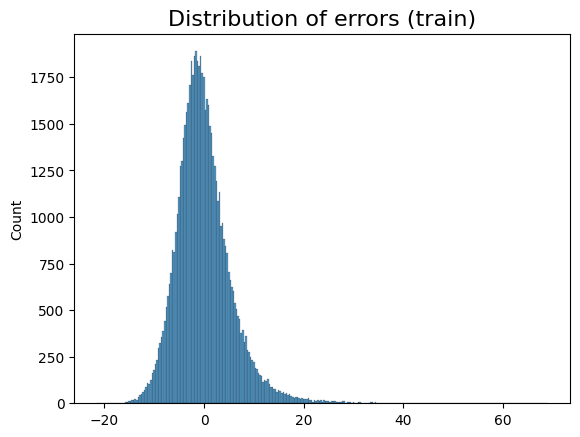

In [137]:
sns.histplot(y_train - pred_train).set_title("Distribution of errors (train)", size=16)
plt.show()

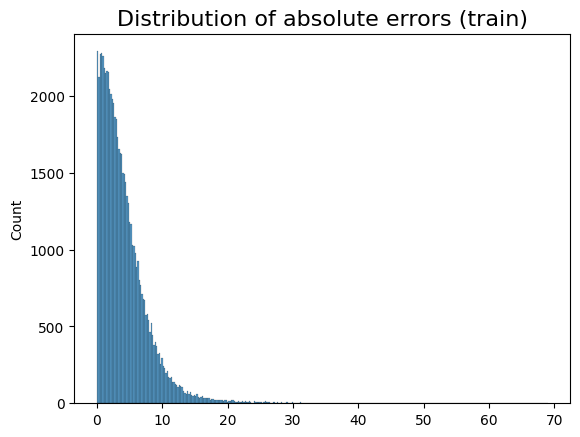

In [138]:
sns.histplot(np.abs(y_train - pred_train)).set_title("Distribution of absolute errors (train)", size=16)
plt.show()

In [139]:
pred_test = results.predict(X_test)

print('Naïve Testing MAE:', mae(y_test, np.mean(y_test))) #naive mae
print('Testing MAE:', mae(y_test, pred_test)) # mae

Naïve Testing MAE: 6.26
Testing MAE: 4.1


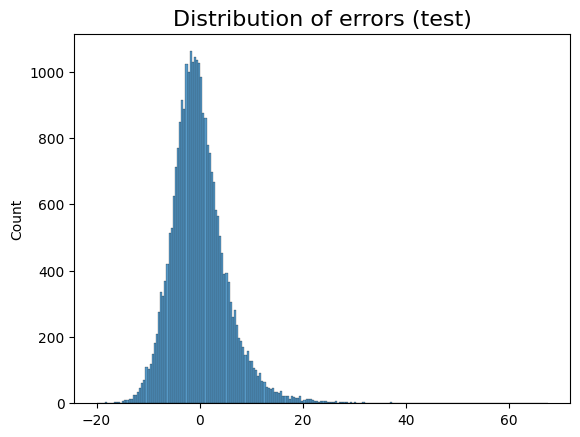

In [140]:
sns.histplot(y_test - pred_test).set_title("Distribution of errors (test)", size=16)
plt.show()

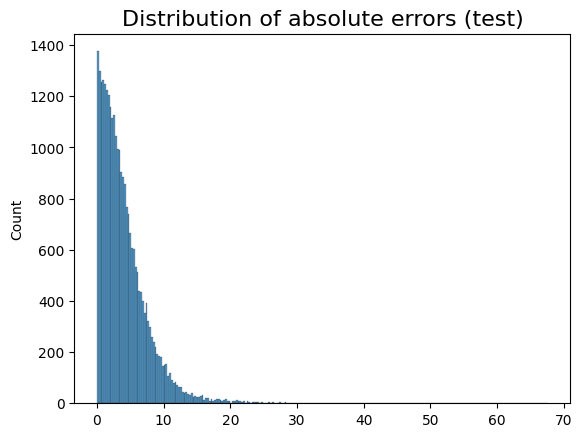

In [141]:
sns.histplot(np.abs(y_test - pred_test)).set_title("Distribution of absolute errors (test)", size=16)
plt.show()